# Phase-separated giant unilamellar vesicles (GUVs)

In [1]:
import numpy as np
import deeptrack as dt
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from scipy.ndimage import map_coordinates

np.random.seed(7)

/Users/guillem/miniforge3/envs/deeptrack2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/guillem/miniforge3/envs/deeptrack2/lib/python3.11/site-packages/deeptrack/backend/_config.py:200: UserWarning: OpenCV (cv2) is not installed. Some image processing features will be unavailable.
  warnings.warn(


Helper functions

In [2]:
IMAGE_SIZE = 400
PIXEL_SIZE_UM = 1.0 / 7.0  # resolution (1 um) / magnification (7)

optics = dt.Fluorescence(
    wavelength=500e-9,
    NA=1.2,
    resolution=1e-6,
    magnification=7,
    refractive_index_medium=1.33,
    output_region=(0, 0, IMAGE_SIZE, IMAGE_SIZE),
)


def vesicle_ring(position, radius, intensity=1.0, shell_ratio=1.08):
    """A hollow-shell 'vesicle': a negative sphere is cancelled by a larger
    positive sphere everywhere except in the thin shell between them, the same
    construction used for the Noctiluca scatterers in DTEx206."""
    inner = dt.Sphere(position=position, radius=radius, intensity=-intensity)
    outer = dt.Sphere(
        position=inner.position,
        radius=inner.radius * shell_ratio,
        intensity=inner.intensity * -1,
    )
    return inner >> outer


def render(scatterer):
    return np.squeeze(np.array(optics(scatterer).resolve()))


def normalize(image, percentile=99.5):
    peak = np.percentile(image, percentile)
    return np.clip(image / max(peak, 1e-9), 0, 1)


def angle_map(shape, center_px):
    """Angle (degrees, 0-360) of every pixel relative to center_px."""
    yy, xx = np.mgrid[0 : shape[0], 0 : shape[1]]
    return (np.degrees(np.arctan2(yy - center_px[0], xx - center_px[1])) + 360) % 360


def domain_mask(shape, center_px, angle_ranges):
    ang = angle_map(shape, center_px)
    mask = np.zeros(shape, dtype=bool)
    for lo, hi in angle_ranges:
        mask |= (ang >= lo) & (ang < hi) if lo < hi else (ang >= lo) | (ang < hi)
    return mask


def add_scalebar(ax, length_um=5, color="white"):
    ax.add_artist(AnchoredSizeBar(
        ax.transData, length_um / PIXEL_SIZE_UM, f"{length_um} \u00b5m",
        loc="lower right", pad=0.4, color=color, frameon=False,
        size_vertical=2, fontproperties={"size": 11, "weight": "bold"},
    ))


green_cmap = LinearSegmentedColormap.from_list("lo_green", ["#000000", "#00ff00"])
red_cmap = LinearSegmentedColormap.from_list("ld_red", ["#000000", "#ff0000"])

In [3]:
green_ac = np.zeros((IMAGE_SIZE, IMAGE_SIZE))
red_ac = np.zeros((IMAGE_SIZE, IMAGE_SIZE))

main_vesicle_ring = render(vesicle_ring(position=(230, 190), radius=9e-6, shell_ratio=1.06))
green_ac = np.maximum(green_ac, main_vesicle_ring)
red_ac = np.maximum(red_ac, main_vesicle_ring * 0.06)  # faint bleed-through, not a real domain

for position in [(75, 320), (95, 345)]:
    ring = render(vesicle_ring(position=position, radius=2.6e-6, shell_ratio=1.12))
    green_ac = np.maximum(green_ac, ring)
    red_ac = np.maximum(red_ac, ring)

green_ac, red_ac = normalize(green_ac), normalize(red_ac)
merge_ac = np.stack([red_ac, green_ac, np.zeros_like(green_ac)], axis=-1)

In [4]:
center_px = (200, 200)
shell_radius_um = 8.0
shell_radius_px = shell_radius_um / PIXEL_SIZE_UM
domain_angle_ranges = [(160, 205), (250, 280), (300, 330)]  # Ld domains, degrees

ring_dg = render(vesicle_ring(position=center_px, radius=shell_radius_um * 1e-6, shell_ratio=1.07))

yy, xx = np.mgrid[0 : ring_dg.shape[0], 0 : ring_dg.shape[1]]
radius_map = np.hypot(yy - center_px[0], xx - center_px[1])
annulus = np.abs(radius_map - shell_radius_px) < shell_radius_px * 0.2

domain = domain_mask(ring_dg.shape, center_px, domain_angle_ranges) & annulus

# Both channels share one normalisation, so a domain swap near the membrane
# doesn't rescale the faint PSF halo elsewhere into a false signal.
peak = np.percentile(ring_dg, 99.5)
green_dg = np.clip(np.where(domain, 0.0, ring_dg) / peak, 0, 1)
red_dg = np.clip(np.where(domain, ring_dg, 0.0) / peak, 0, 1)
merge_dg = np.stack([red_dg, green_dg, np.zeros_like(green_dg)], axis=-1)

In [5]:
# Line profile through an Ld domain (~182 deg, inside the 160-205 deg range)
# and the Lo region on the opposite side of the vesicle.
theta = np.radians(182)
direction = np.array([np.sin(theta), np.cos(theta)])  # (row, col)
p0 = np.array(center_px) + 1.3 * shell_radius_px * direction  # starts in the Ld domain
p1 = np.array(center_px) - 1.3 * shell_radius_px * direction  # ends in the Lo region

n_samples = 400
line = np.linspace(p0, p1, n_samples)
green_profile = map_coordinates(green_dg, line.T, order=1)
red_profile = map_coordinates(red_dg, line.T, order=1)
distance_um = np.linspace(0, np.linalg.norm(p1 - p0) * PIXEL_SIZE_UM, n_samples)

## Assemble the figure

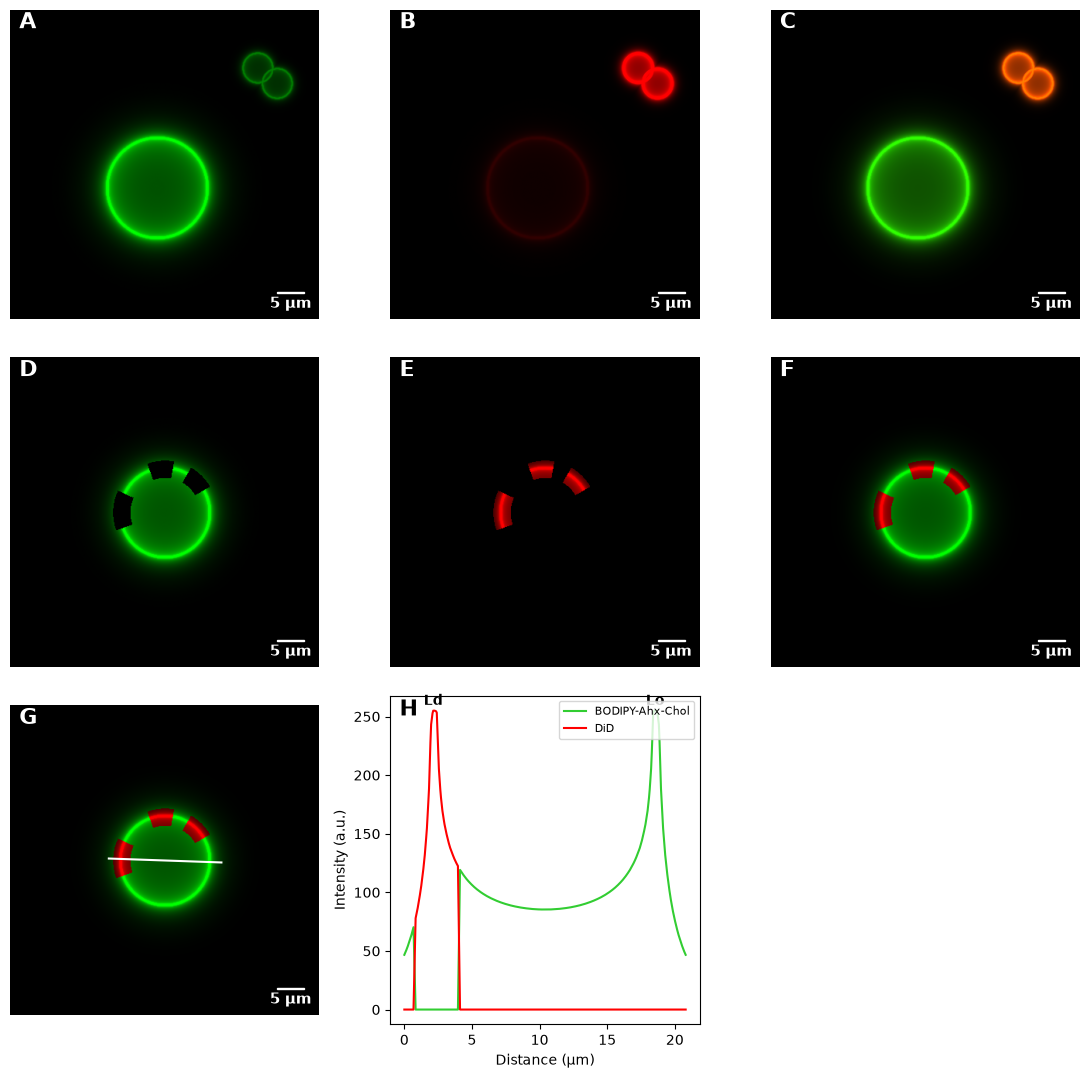

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax in axes.ravel():
    ax.axis("off")

(panelA, panelB, panelC), (panelD, panelE, panelF), (panelG, panelH, blank) = axes
blank.axis("off")


def show(ax, image, cmap, letter):
    ax.imshow(image, cmap=cmap, vmin=0, vmax=1)
    add_scalebar(ax)
    ax.text(0.03, 0.94, letter, transform=ax.transAxes, color="white",
            fontsize=16, fontweight="bold")


def show_merge(ax, image, letter):
    ax.imshow(image)
    add_scalebar(ax)
    ax.text(0.03, 0.94, letter, transform=ax.transAxes, color="white",
            fontsize=16, fontweight="bold")


show(panelA, green_ac, green_cmap, "A")
show(panelB, red_ac, red_cmap, "B")
show_merge(panelC, merge_ac, "C")

show(panelD, green_dg, green_cmap, "D")
show(panelE, red_dg, red_cmap, "E")
show_merge(panelF, merge_dg, "F")

show_merge(panelG, merge_dg, "G")
panelG.plot([p0[1], p1[1]], [p0[0], p1[0]], color="white", lw=1.5)

panelH.axis("on")
panelH.plot(distance_um, green_profile * 255, color="limegreen", label="BODIPY-Ahx-Chol")
panelH.plot(distance_um, red_profile * 255, color="red", label="DiD")
panelH.set_xlabel("Distance (\u00b5m)")
panelH.set_ylabel("Intensity (a.u.)")
panelH.legend(fontsize=8, loc="upper right")
panelH.text(0.03, 0.94, "H", transform=panelH.transAxes, fontsize=16, fontweight="bold")
panelH.annotate("Ld", (distance_um[np.argmax(red_profile)], 260), ha="center", fontweight="bold")
panelH.annotate("Lo", (distance_um[np.argmax(green_profile)], 260), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()